# Data Mining Project Template (GitHub + Colab)
## Eliza Liva Kalnina
## 04/24/2026
## CTR in Adverisement

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**



In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Deliverable 1: Problem Framing & Data Acquisition


The goal of this project is to predict whether an online advertisement will receive a click based on its features. This is important because companies can use these predictions to improve ad performance and increase engagement.

The target variable is whether an advertisement is clicked (1) or not clicked (0).

This project is in the digital marketing domain. Businesses use online ads to reach customers, and predicting which ads will perform well helps improve marketing strategies.

Predicting ad clicks helps companies save money and focus on effective ads, improving overall marketing efficiency.

The dataset was sourced from Kaggle (CTR in Advertisement dataset).

I chose this dataset because I am interested in working in digital marketing and analytics, and this project helps me better understand how advertisement performance can be analyzed and predicted.


In [ ]:
# Option A: Load from a direct CSV URL
# Example:
# data_url = "https://raw.githubusercontent.com/yourusername/yourrepo/main/data/yourfile.csv"
# df = pd.read_csv(data_url)


# Replace this with your own dataset path or URL
data_path = "Ad_click_prediction_train (1).csv"
df = pd.read_csv(data_path)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

In [ ]:
df.head()

,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation




In [ ]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (463291, 15)


,session_id,DateTime,user_id,product,campaign_id,webpage_id,product_category_1,product_category_2,user_group_id,gender,age_level,user_depth,city_development_index,var_1,is_click
0,140690,2017-07-02 00:00,858557,C,359520,13787,4,NaN,10.0,Female,4.0,3.0,3.0,0,0
1,333291,2017-07-02 00:00,243253,C,105960,11085,5,NaN,8.0,Female,2.0,2.0,NaN,0,0
2,129781,2017-07-02 00:00,243253,C,359520,13787,4,NaN,8.0,Female,2.0,2.0,NaN,0,0
3,464848,2017-07-02 00:00,1097446,I,359520,13787,3,NaN,3.0,Male,3.0,3.0,2.0,1,0
4,90569,2017-07-02 00:01,663656,C,405490,60305,3,NaN,2.0,Male,2.0,3.0,2.0,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463291 entries, 0 to 463290
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              463291 non-null  int64  
 1   DateTime                463291 non-null  object 
 2   user_id                 463291 non-null  int64  
 3   product                 463291 non-null  object 
 4   campaign_id             463291 non-null  int64  
 5   webpage_id              463291 non-null  int64  
 6   product_category_1      463291 non-null  int64  
 7   product_category_2      97437 non-null   float64
 8   user_group_id           445048 non-null  float64
 9   gender                  445048 non-null  object 
 10  age_level               445048 non-null  float64
 11  user_depth              445048 non-null  float64
 12  city_development_index  338162 non-null  float64
 13  var_1                   463291 non-null  int64  
 14  is_click            

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
session_id,463291.0,NaN,NaN,NaN,285544.090725,168577.345887,2.0,137856.5,285429.0,435535.5,595812.0
DateTime,463291,8610,2017-07-04 20:39,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,463291.0,NaN,NaN,NaN,546049.654772,329462.525854,4.0,257855.0,531801.0,827849.0,1141729.0
product,463291,10,C,163501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign_id,463291.0,NaN,NaN,NaN,308474.540069,126517.101294,82320.0,118601.0,359520.0,405490.0,414149.0
webpage_id,463291.0,NaN,NaN,NaN,29685.878994,21542.053106,1734.0,13787.0,13787.0,53587.0,60305.0
product_category_1,463291.0,NaN,NaN,NaN,3.072427,1.304233,1.0,2.0,3.0,4.0,5.0
product_category_2,97437.0,NaN,NaN,NaN,162753.345105,78743.74272,18595.0,82527.0,146115.0,254132.0,450184.0
user_group_id,445048.0,NaN,NaN,NaN,3.477396,2.412889,0.0,2.0,3.0,4.0,12.0
gender,445048,2,Male,393454,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0
product_category_2,365854
city_development_index,125129
gender,18243
user_group_id,18243
age_level,18243
user_depth,18243


I analyzed missing values in the dataset and found that some features have a large number of missing entries. For example, product_category_2 has the highest number of missing values, followed by city_development_index. Other features such as gender, user_group_id, age_level, and user_depth also contain missing values.

This indicates that data preprocessing will be necessary before training models. These missing values can be handled by either filling them in (imputation) or removing the columns, depending on their importance.

In [ ]:
# TODO: Replace with your actual target column name
target = "is_click"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
is_click,
0,431960
1,31331


,proportion
is_click,
0,0.932373
1,0.067627


I analyzed the target variable (is_click) and found that the dataset is highly imbalanced. About 93% of users did not click on ads, while only about 7% did.

This imbalance means that accuracy alone is not a reliable evaluation metric, since a model could predict “no click” most of the time and still achieve high accuracy. Therefore, other metrics such as precision, recall, and F1-score are more appropriate for evaluating model performance.

## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.



In [ ]:
%matplotlib inline

!pip install autoviz
from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


    Since nrows is smaller than dataset, loading random sample of 150000 rows into pandas...
Shape of your Data Set loaded: (150000, 15)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  5
    Number of Integer-Categorical Columns =  4
    Number of String-Categorical Columns =  1
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  1
    Number of Numeric-Boolean Columns =  1
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  1
    Number of Date Time Columns =  0
    Number of ID Columns =  1
    Number of Columns to Delete =  0
    14 Predictors classified...
        1 variable(s) removed since they were ID or low-information variables
        

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
DateTime,object,0.000000,5,,,No issue
user_id,int64,0.000000,53,6.000000,1141729.000000,No issue
product,object,0.000000,0,,,No issue
campaign_id,int64,0.000000,0,82320.000000,414149.000000,No issue
webpage_id,int64,0.000000,0,1734.000000,60305.000000,No issue
product_category_1,int64,0.000000,0,1.000000,5.000000,No issue
product_category_2,float64,79.066429,NA,18595.000000,450184.000000,"117858 missing values. Impute them with mean, median, mode, or a constant value such as 123."
user_group_id,float64,3.946009,NA,0.000000,12.000000,"5882 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 16120 outliers greater than upper bound (7.00) or lower than lower bound(-1.00). Cap them or remove them."
gender,object,3.946009,0,,,"5882 missing values. Impute them with mean, median, mode, or a constant value such as 123., Mixed dtypes: has 2 different data types: object, float,"
age_level,float64,3.946009,NA,0.000000,6.000000,"5882 missing values. Impute them with mean, median, mode, or a constant value such as 123., Column has 10825 outliers greater than upper bound (4.50) or lower than lower bound(0.50). Cap them or remove them."


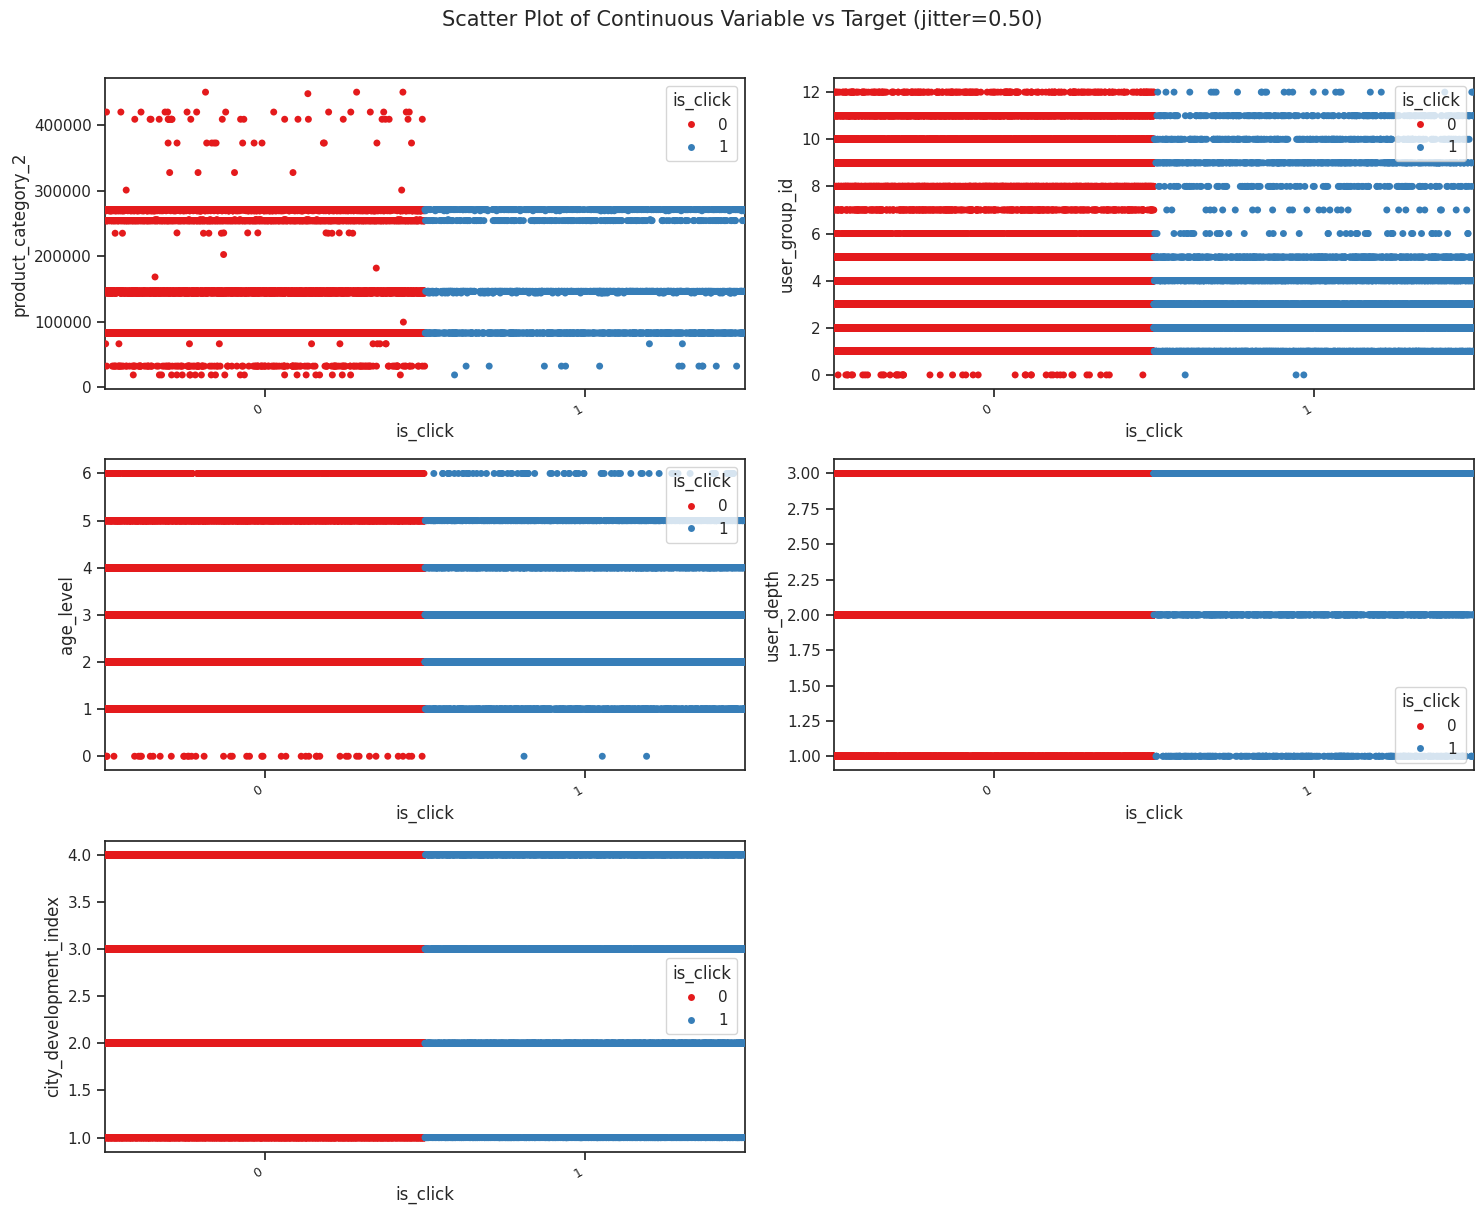

Total Number of Scatter Plots = 15


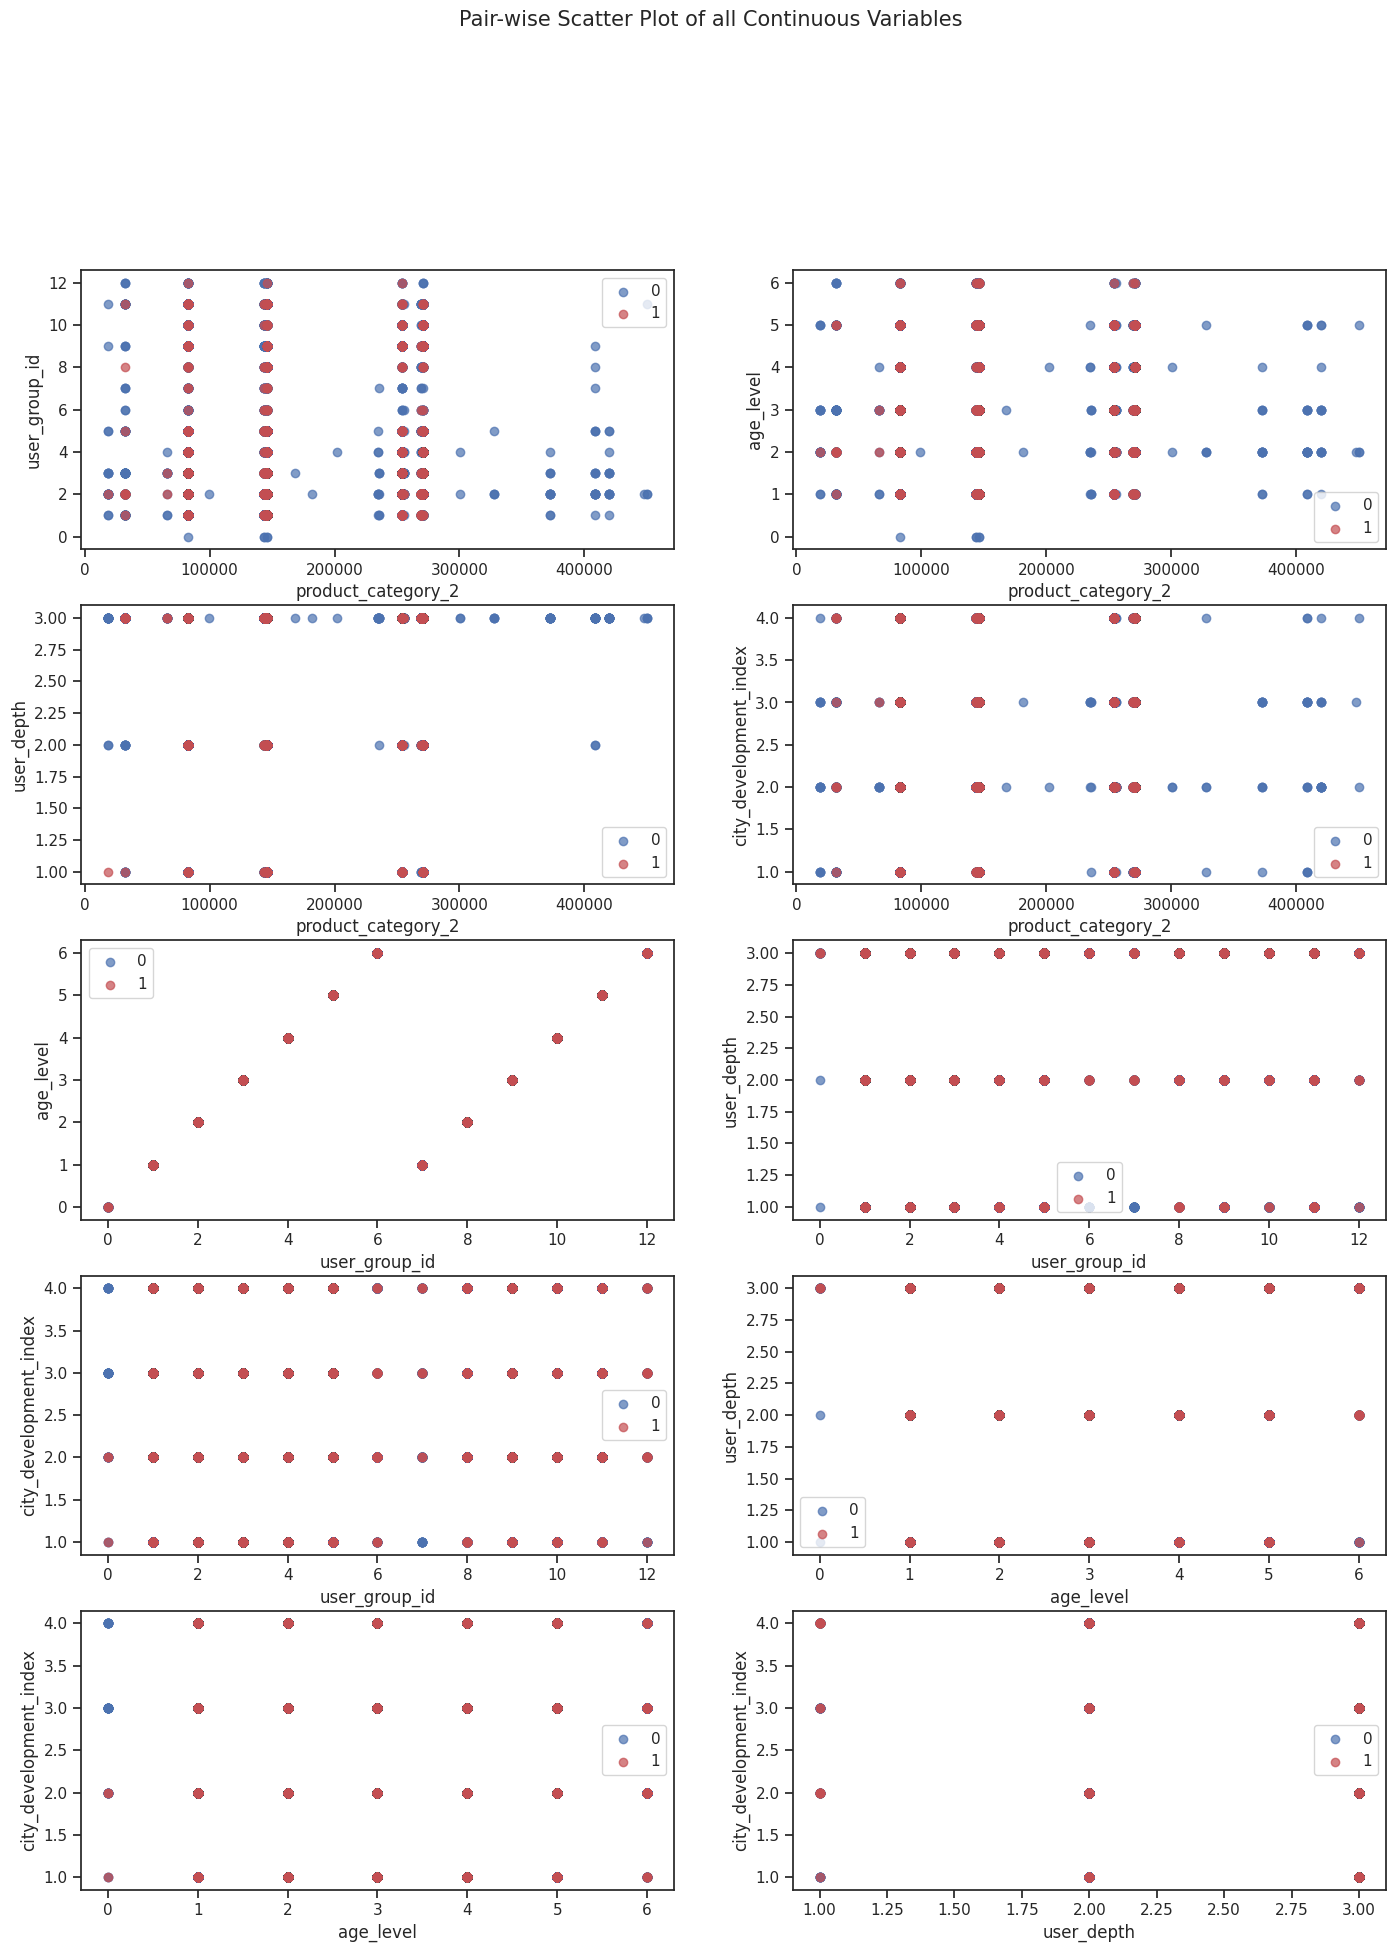

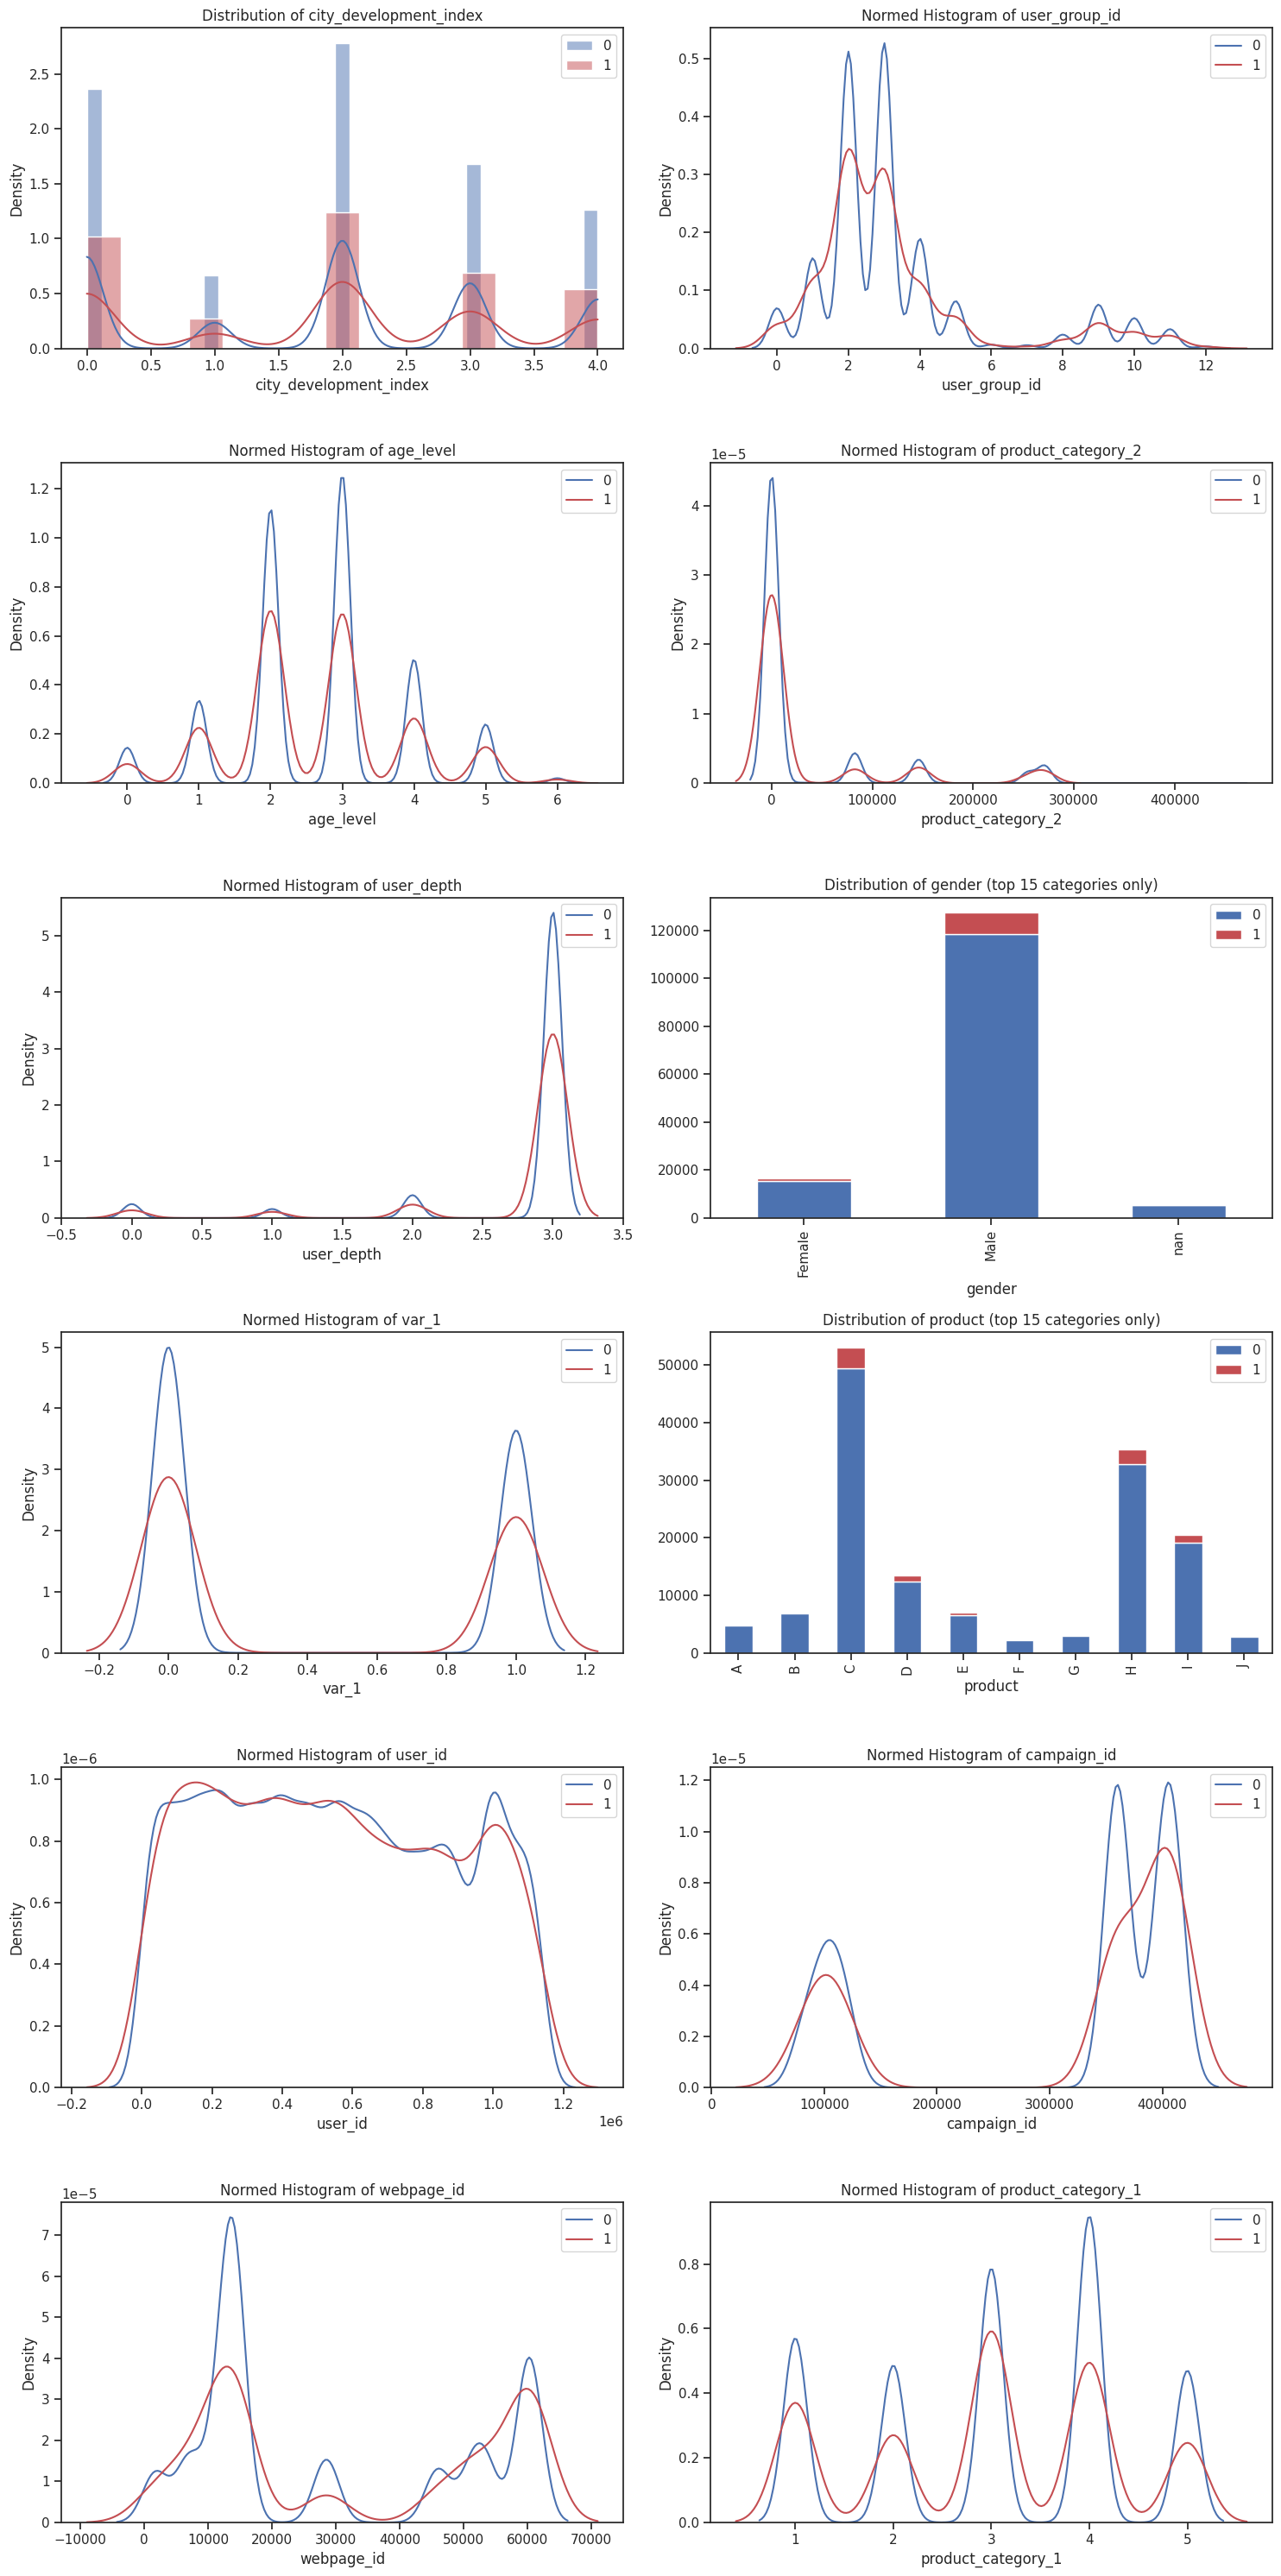

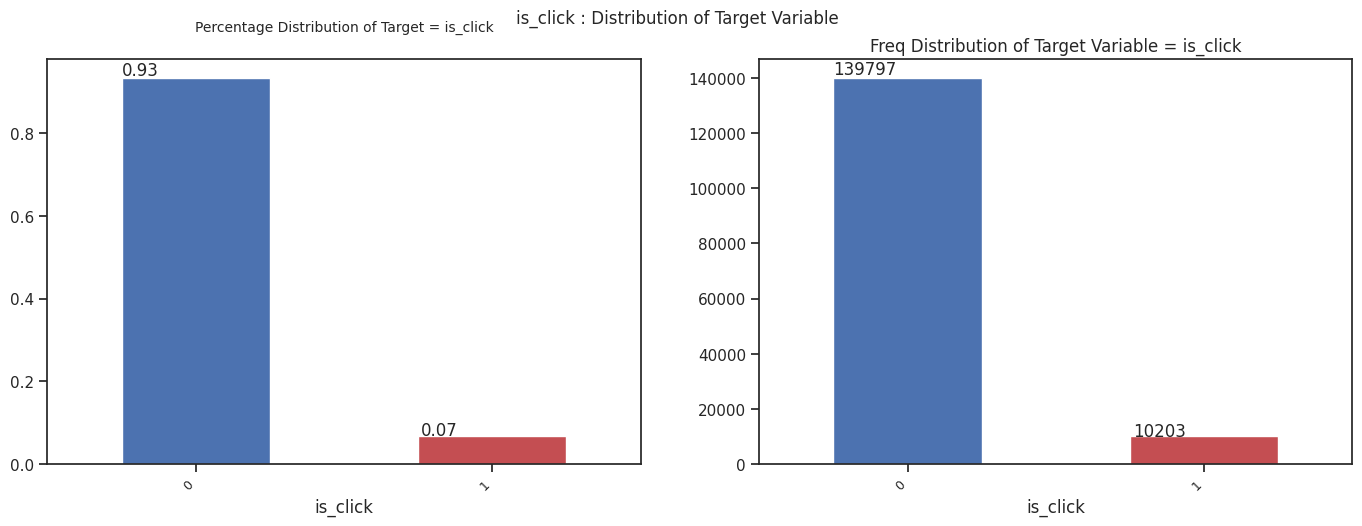

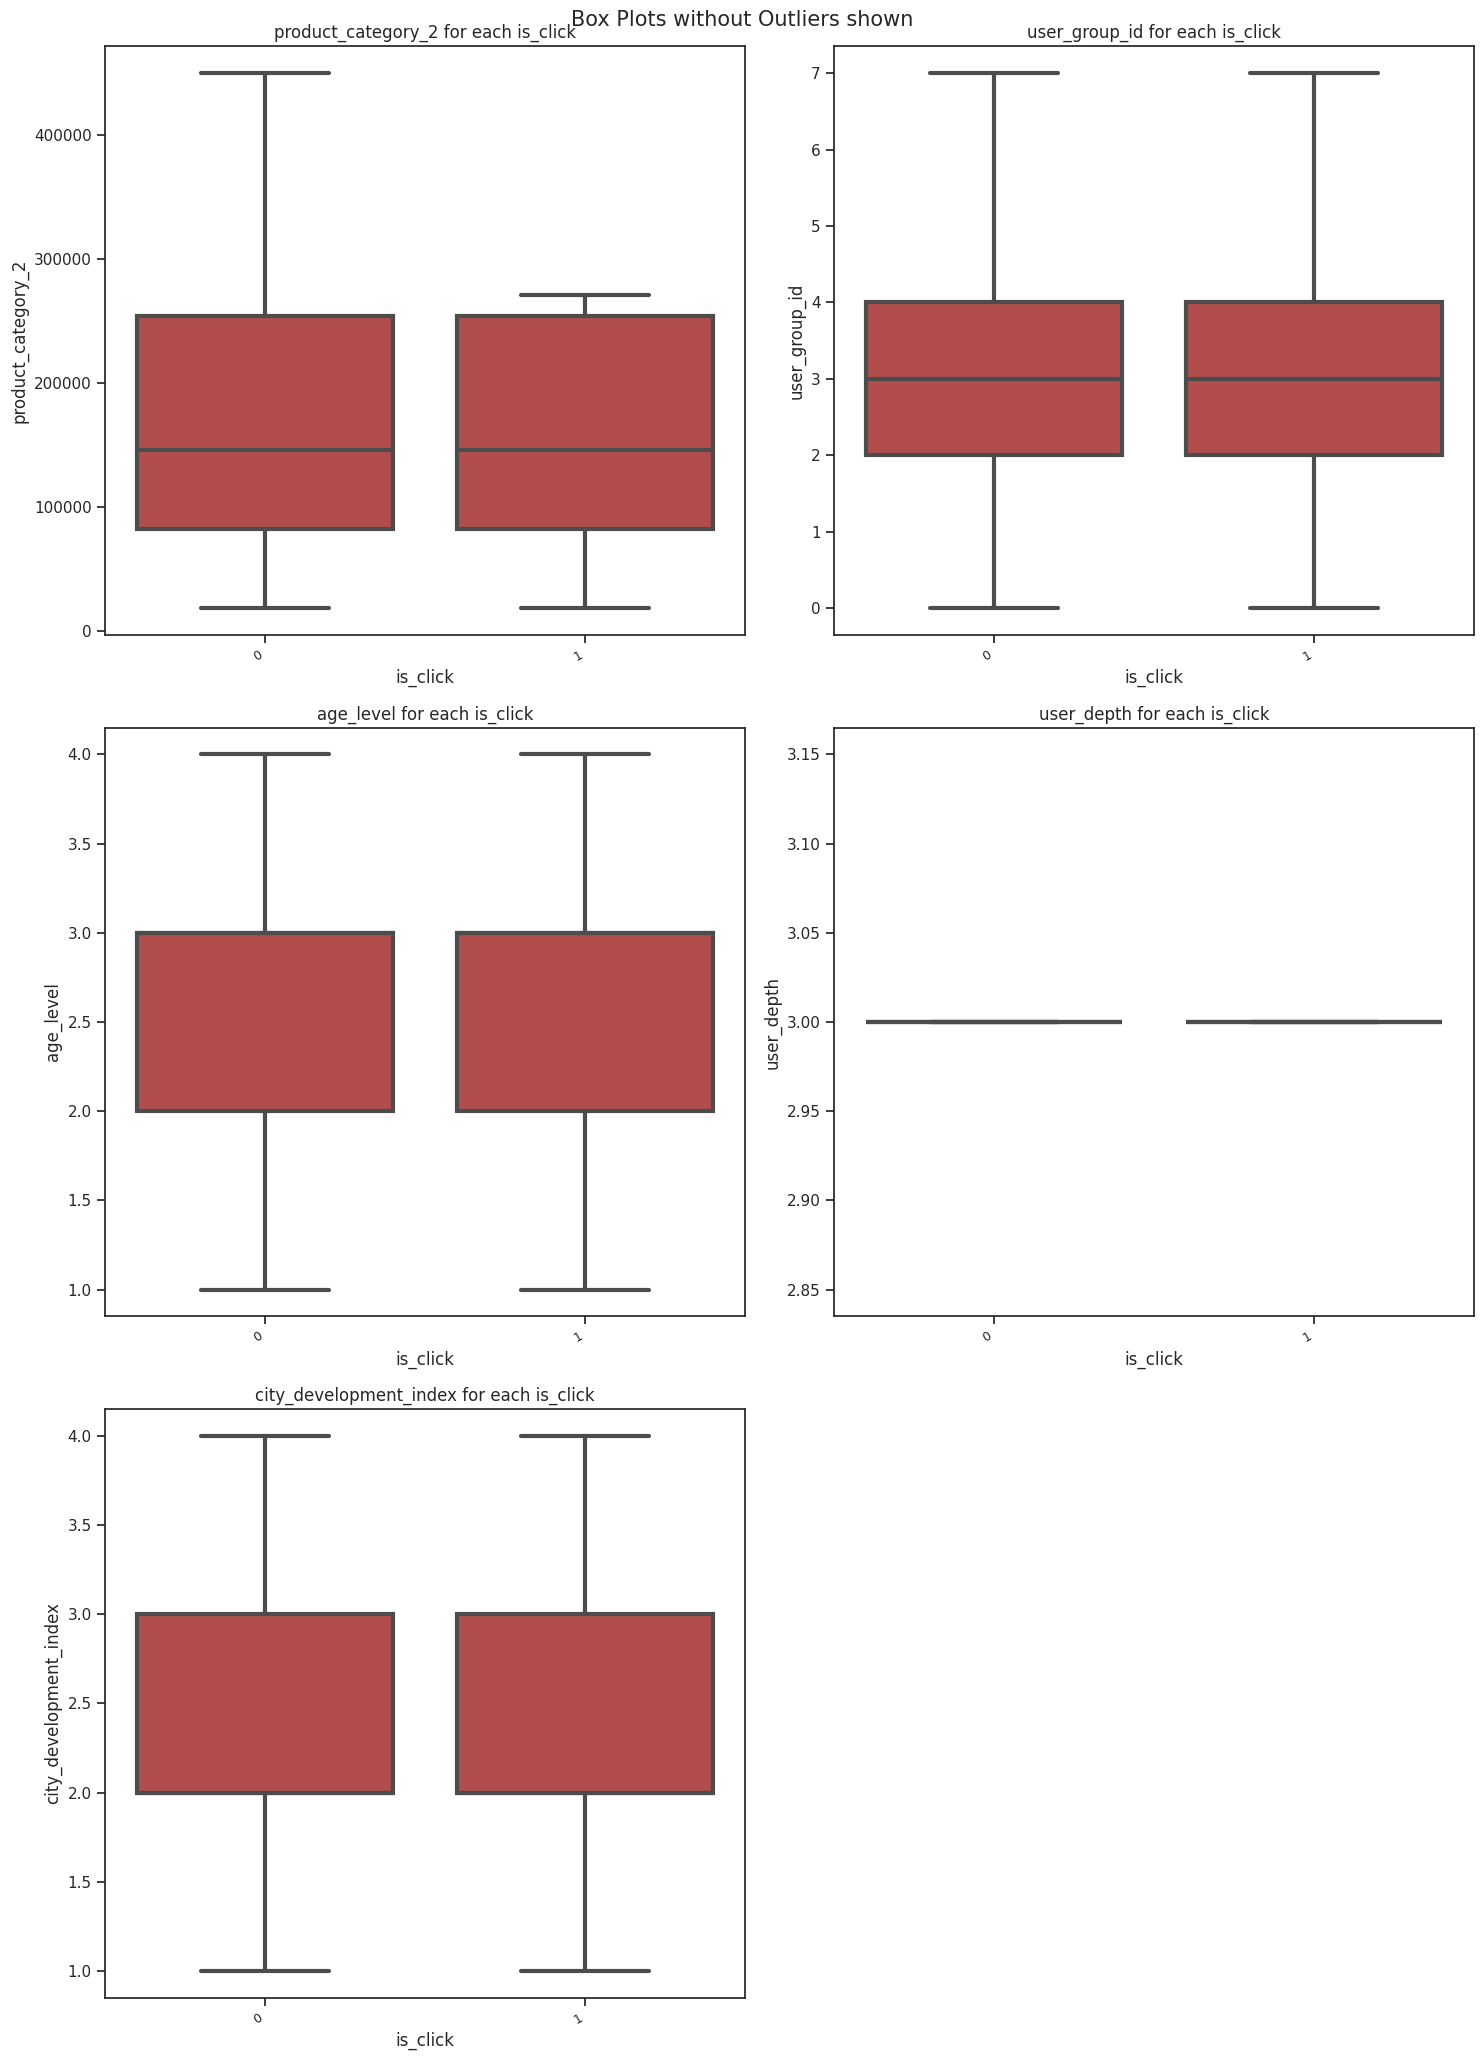

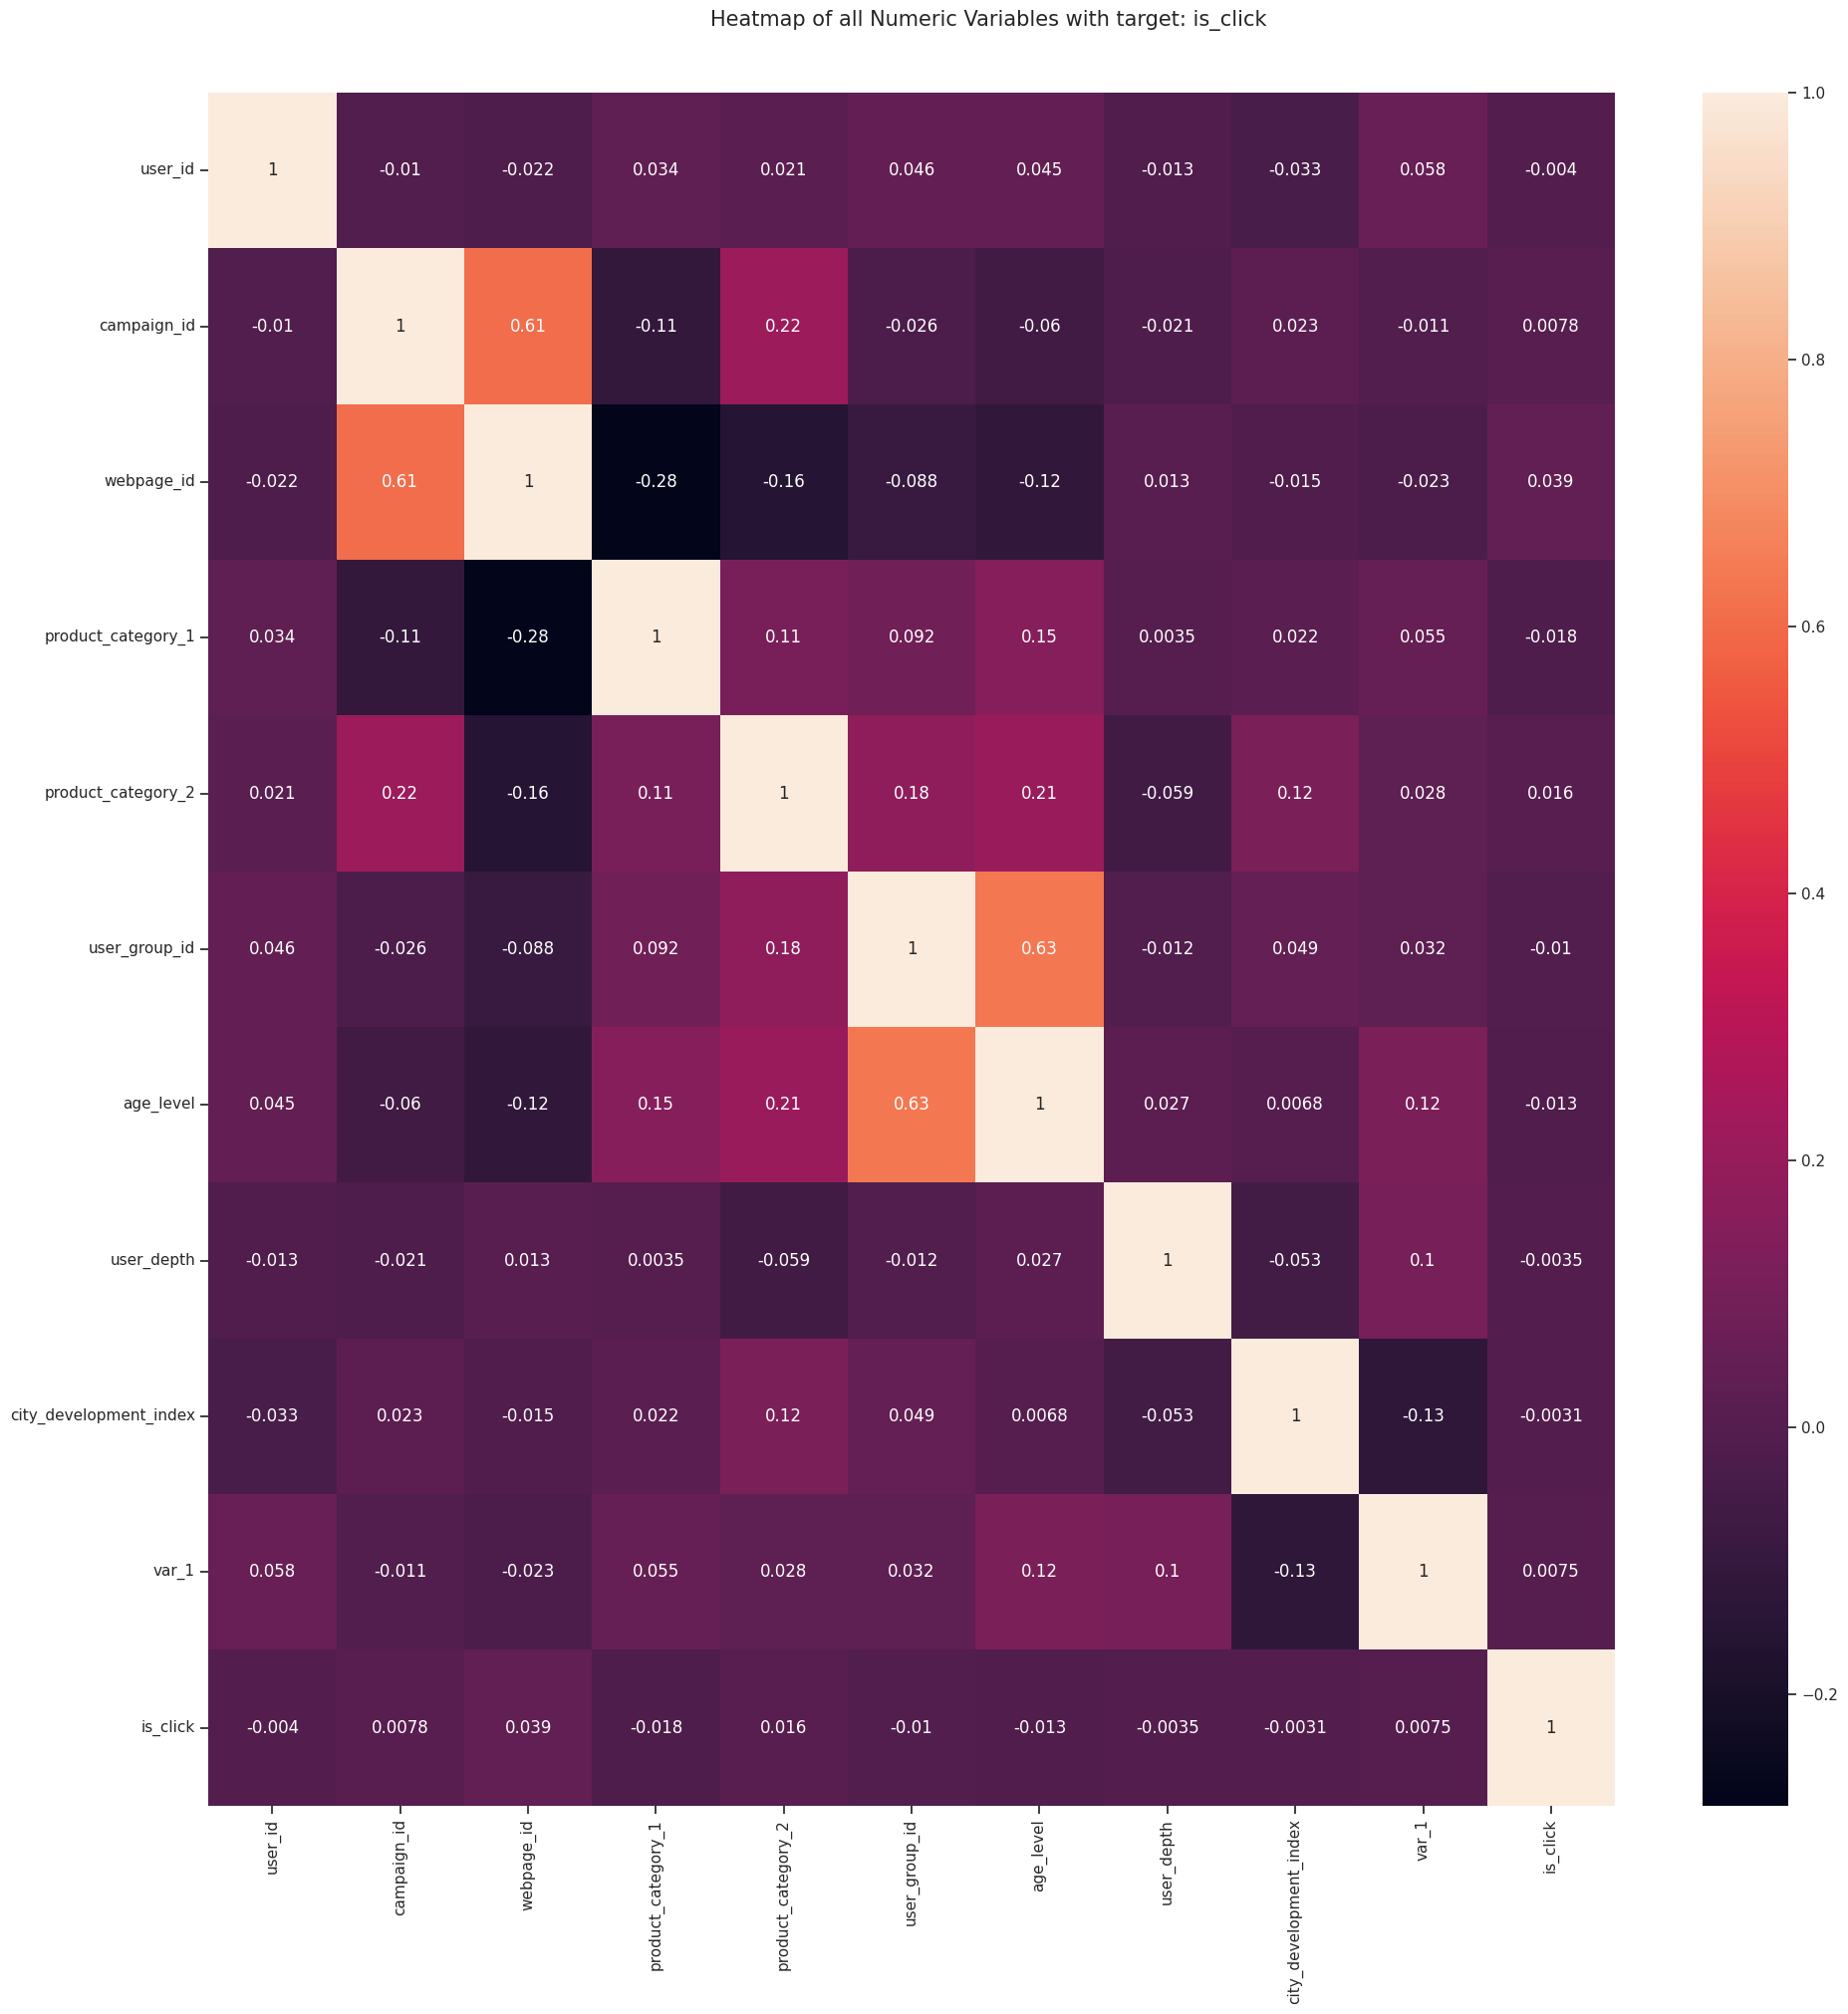

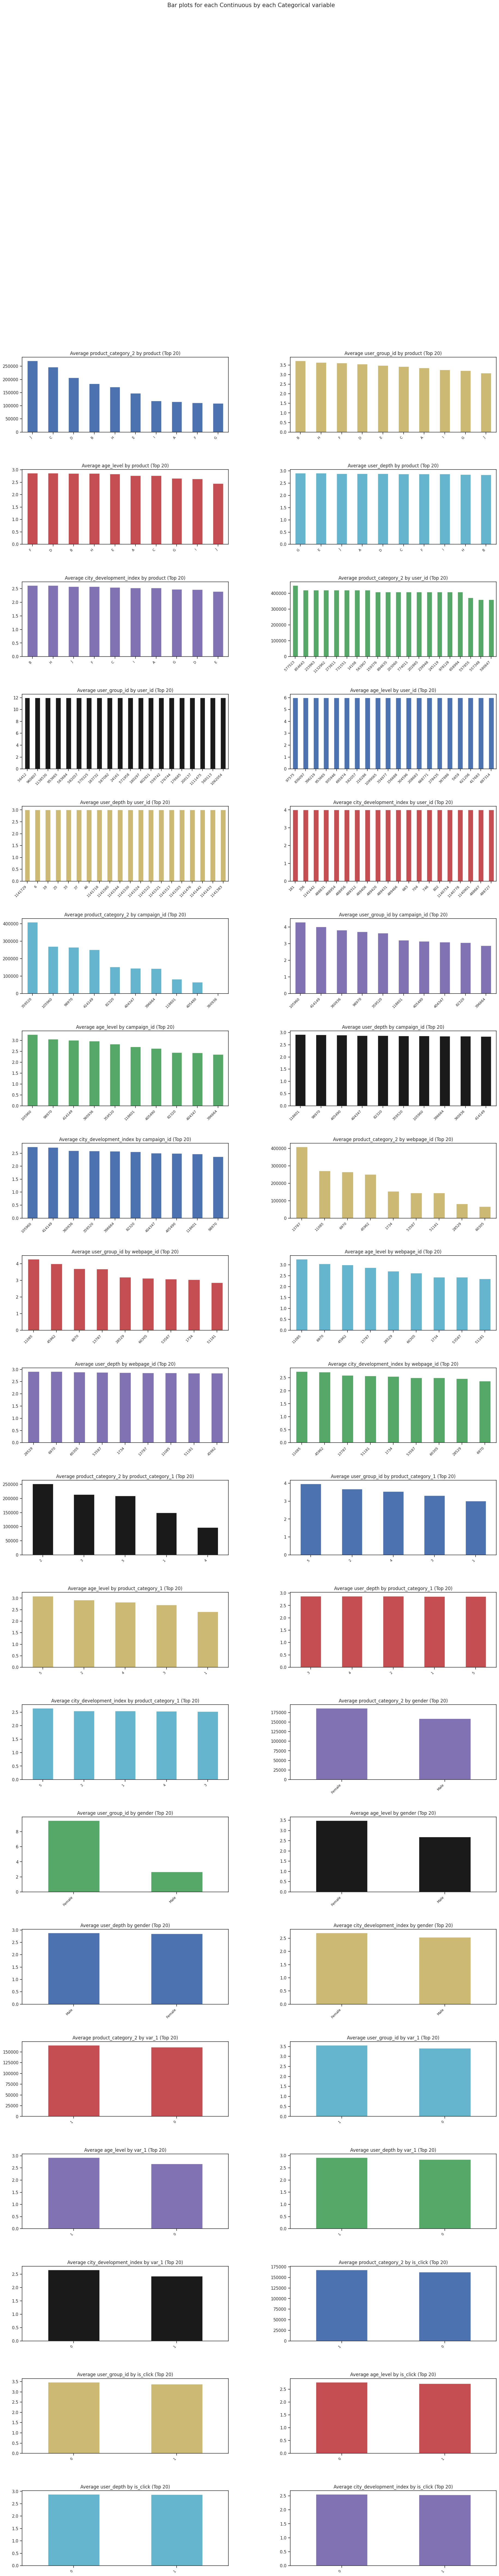

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

Could not draw wordcloud plot for DateTime. 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

All Plots done
Time to run AutoViz = 96 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [ ]:
dfte = AV.AutoViz(
    "",
    sep=",",
    depVar="is_click",
    dfte=df,
    header=0,
    verbose=1,
    lowess=False,
    chart_format="svg",
    max_rows_analyzed=150000,
    max_cols_analyzed=30
)
import matplotlib.pyplot as plt
plt.close('all')


What I learned from AutoViz

From this exploratory data analysis I learned that the target variable (is_click) is unbalanced, meaning most users do not click on ads. Because of this, accuracy alone might not be the best way to measure model performance, and other metrics like precision and recall could be more useful.
I also saw that some columns have a lot of missing values. For example, product_category_2 is missing a large portion of its data, and city_development_index also has many missing values. These will need to be handled, either by filling them in or removing them, before building models.
In addition, there are some duplicate rows and outliers in features like age_level and user_depth, which could affect the model. The dataset also has both numerical and categorical data, so encoding and scaling has to be done before training models.
Overall, this analysis helped me understand the data set better and what I can get from it.

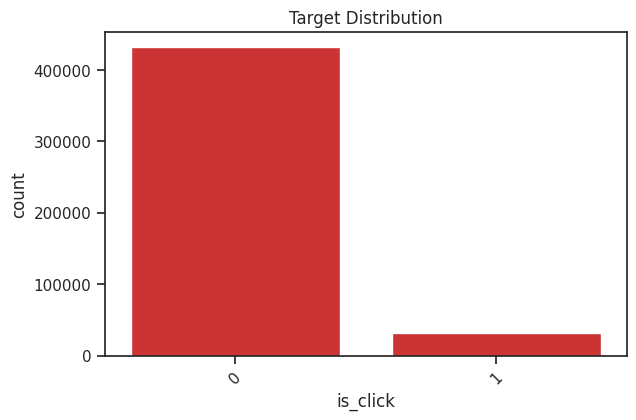

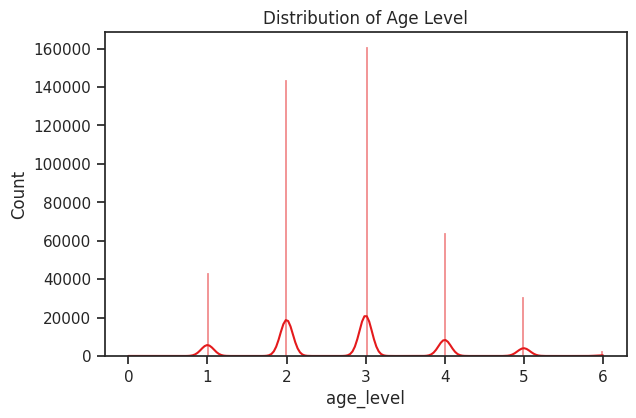

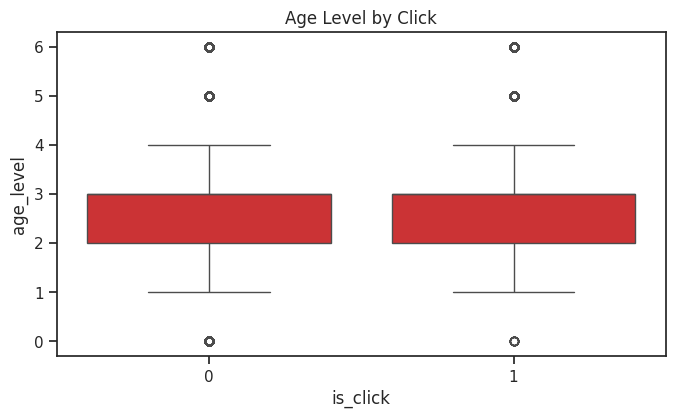

In [ ]:
# Example 1: target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Target Distribution")
plt.xticks(rotation=45)
plt.show()

# Example 2: numeric histogram for one variable
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='age_level', kde=True)
plt.title("Distribution of Age Level")
plt.show()

# Example 3: relationship to target
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x=target, y='age_level')
plt.title("Age Level by Click")
plt.show()


### Data Preparation Summary

- Columns such as session_id and user_id may be dropped because they do not provide predictive value.

- Missing values were observed in columns like product_category_2, city_development_index, gender, and user_group_id. Notably, product_category_2 has a very high percentage of missing values (~79%), so it may be dropped or carefully imputed. Other missing values will be handled using imputation (e.g., median for numerical variables and mode for categorical variables).

- Categorical variables such as product and gender will be encoded using techniques like one-hot encoding or label encoding.

- The dataset is highly imbalanced (most users do not click ads), so evaluation metrics such as precision, recall, and F1-score will be used. Techniques like class weighting or resampling may also be applied.

- Variables such as age_level show similar distributions across target classes, suggesting limited predictive power individually. Feature combinations or engineering may be needed.

- Numerical features may require scaling due to differences in value ranges across variables.

- The dataset will be split into training and testing sets (e.g., 80/20 split) to evaluate model performance.

- Feature engineering may include transforming the DateTime column into useful features such as hour, day, or weekday.

# Deliverable 3: Model Development, Evaluation & Interpretation



In [ ]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [ ]:
# Identify feature columns

target = "is_click"

# Create useful date/time features
df["DateTime"] = pd.to_datetime(df["DateTime"])
df["hour"] = df["DateTime"].dt.hour
df["dayofweek"] = df["DateTime"].dt.dayofweek

# Drop target and columns that are IDs or too unique
drop_cols = [
    target,
    "session_id",
    "user_id",
    "DateTime"
]

X = df.drop(columns=drop_cols)
y = df[target]

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)


Categorical columns: ['product', 'gender']
Numeric columns: ['campaign_id', 'webpage_id', 'product_category_1', 'product_category_2', 'user_group_id', 'age_level', 'user_depth', 'city_development_index', 'var_1', 'hour', 'dayofweek']
X shape: (463291, 13)
y shape: (463291,)


In this step, the target variable is_click is defined as the outcome to be predicted. The DateTime column is converted into a proper datetime format, and new features such as hour and dayofweek are extracted to capture potential time-based patterns in user behavior. Columns that do not provide meaningful predictive value, such as unique identifiers (session_id, user_id) and the original DateTime, are removed. The dataset is then split into input features (X) and the target variable (y). Finally, the remaining features are categorized into categorical and numerical variables to prepare for appropriate preprocessing steps in later stages.

In [ ]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


A preprocessing pipeline is created to prepare the data for modeling. Missing values in numerical features are filled using the median, while categorical features are imputed with the most frequent value and one-hot encoded. These steps are combined using a ColumnTransformer. The data is then split into training and testing sets (80/20), with stratification to maintain the target class distribution.

In [ ]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=123,
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     86393
           1       0.08      0.21      0.12      6266

    accuracy                           0.79     92659
   macro avg       0.51      0.52      0.50     92659
weighted avg       0.88      0.79      0.83     92659

Cohen's Kappa: 0.0249


A baseline Random Forest model is trained using the preprocessing pipeline, with class weighting to address imbalance. Performance is evaluated on the test set using precision, recall, and F1-score. While overall accuracy is high, the model struggles to detect the minority class (clicks), and the low Cohen’s Kappa indicates performance is only slightly better than random.

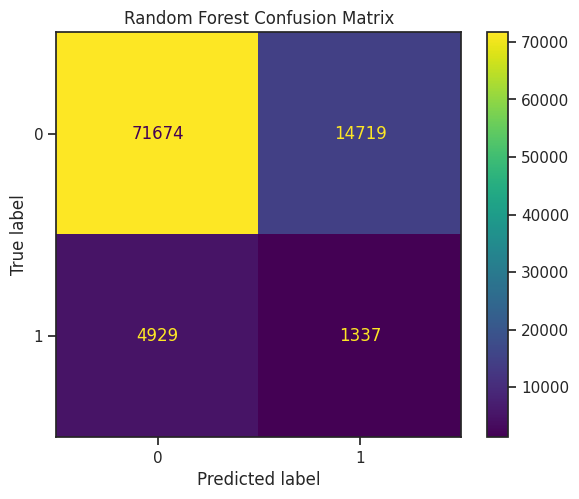

In [ ]:
# Confusion matrix
import matplotlib.pyplot as plt

plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()


## Hyperparameter tuning



In [ ]:
# Tune the Random Forest model
param_grid = {
    "model__max_depth": [10, None]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=123,
        n_estimators=100,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=2,  # reduce folds
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'model__max_depth': None}


In [ ]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88     86393
           1       0.08      0.21      0.12      6266

    accuracy                           0.79     92659
   macro avg       0.51      0.52      0.50     92659
weighted avg       0.88      0.79      0.83     92659

Cohen's Kappa: 0.0248


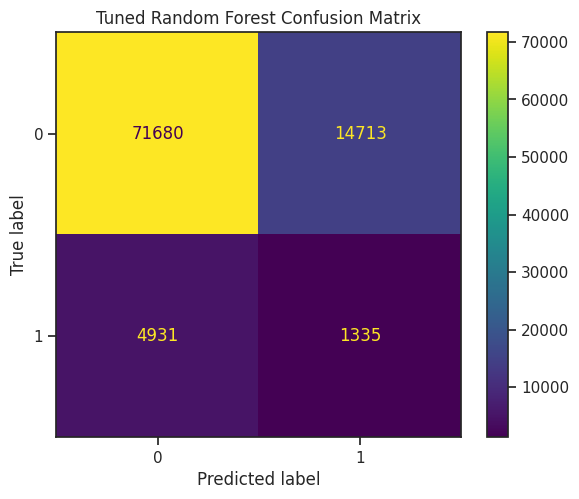

In [ ]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.



In [ ]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


,feature,importance
9,num__hour,0.474601
10,num__dayofweek,0.129333
7,num__city_development_index,0.112589
4,num__user_group_id,0.049280
5,num__age_level,0.046041
6,num__user_depth,0.037184
8,num__var_1,0.029861
2,num__product_category_1,0.026228
0,num__campaign_id,0.020654
1,num__webpage_id,0.016704


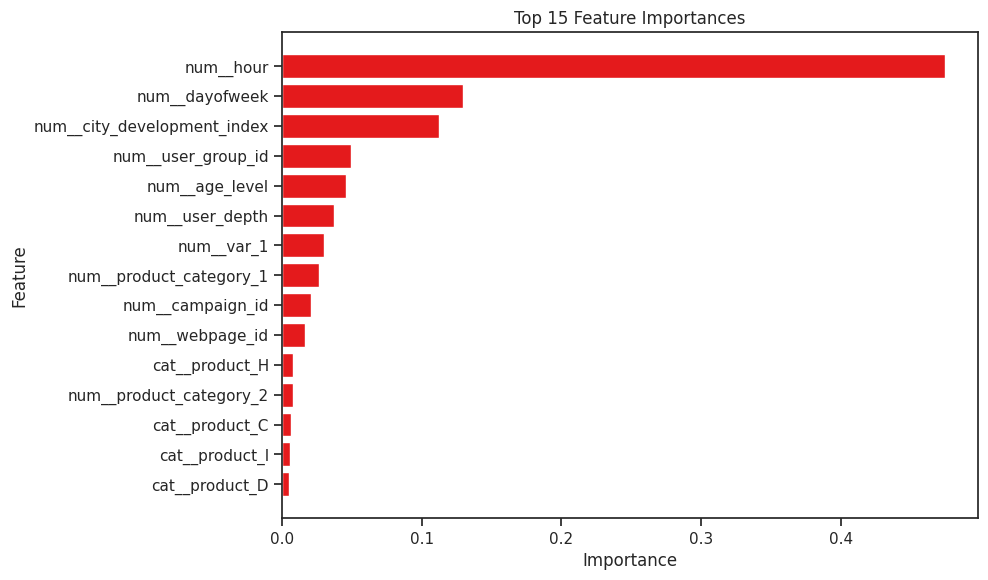

In [ ]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear",
        random_state=123
    ))
])

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, log_preds))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, log_preds), 4))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.54      0.69     86393
           1       0.08      0.53      0.14      6266

    accuracy                           0.54     92659
   macro avg       0.51      0.54      0.41     92659
weighted avg       0.88      0.54      0.65     92659

Cohen's Kappa: 0.0203


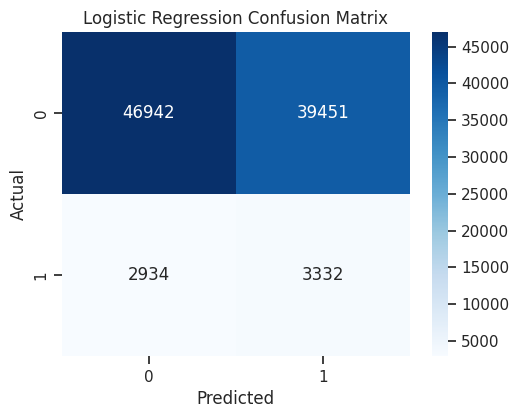

In [ ]:
cm_log = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

As an additional comparison model, Logistic Regression was tested. While it achieved a lower overall accuracy (54%) compared to the Random Forest model (79%), it performed better at identifying the minority class (clicks), with a higher recall (0.53 vs 0.21). This means Logistic Regression was more effective at detecting actual clicks, although it made more mistakes overall. In contrast, Random Forest achieved higher accuracy by favoring the majority class but struggled to detect clicks. This highlights a trade-off between overall accuracy and the ability to identify the minority class.

## Interpretation prompts

- How well did the model perform?

The model achieved an accuracy of 79%, performing well overall due to strong predictions on the majority class. However, its performance on the minority class was weak, with a low F1-score of 0.12, indicating difficulty in identifying positive cases.

- Which class was easier or harder to predict?

The model performed much better on class 0 (non-clicks), which had high precision and recall. Class 1 (clicks) was significantly harder to predict, with low precision and recall, likely due to class imbalance.

- Which variables seemed most important?

The most important variables were hour of the day, day of the week, and city development index, as they had the highest importance scores in the Random Forest model. The hour feature was by far the most influential, suggesting that the timing of when a user sees an advertisement plays a major role in whether they click. Other important factors included user group, age level, and user depth, indicating that both user behavior and demographic characteristics also contribute to prediction.

- Where did the model make mistakes?

The model made most of its mistakes when predicting the minority class (clicks). It often failed to correctly identify actual clicks (false negatives) and sometimes incorrectly predicted clicks where none occurred (false positives).

- How could this model be used by a real organization?

This model could be used by organizations to predict user behavior, such as whether a user will click on an advertisement. This can help optimize marketing strategies, target the right audience, and improve campaign effectiveness.

- What would you improve next?

To improve the model, I would try different models such as logistic regression, decision trees to see if they perform better, especially on the minority class.

### Student interpretation summary
The tuned Random Forest model achieved an overall accuracy of 79%, mainly driven by strong performance on the majority class (non-clicks). However, performance on the minority class (clicks) remains poor, with a low F1-score of 0.12. This indicates difficulty in correctly identifying click events, likely due to the strong class imbalance in the dataset. Despite using class weighting, the model still favors the majority class. The low Cohen’s Kappa score (~0.025) further suggests that the model’s predictions are only slightly better than random chance when accounting for class imbalance.


In [ ]:
import joblib

joblib.dump(best_rf, "final_model.pkl")

print("Model saved as final_model.pkl")

Model saved as final_model.pkl
